# Conversation ANalysis of DYnamics (CANDY): A Tool Demo

## Introduction

### Setup

We begin with setting up the notebook with the necessary Python libraries, paths to directories, and finally a global theme for the plots.

In [1]:
import os
import random
from pathlib import Path
from glob import glob

import pandas as pd
import plotnine as p9

# Set random seed for reproducibility
# why 42? because 42 is the answer to life, the universe and everything (The Hitchhiker's Guide to the Galaxy)
random.seed(42)

# Please change this path to your own data directory
CONVERSATIONS = "data/conversations"

p9.theme_set(
    p9.theme_minimal() + 
    p9.theme(
        figure_size=(10, 5),
        panel_background = p9.element_rect(fill='white'),
        plot_background = p9.element_rect(fill='white'),
        plot_title=p9.element_text(color='black', size=16, weight='bold'),
        axis_line=p9.element_line(color='black'),
        axis_title=p9.element_text(color='black', size=14),
        axis_text=p9.element_text(color='black', size=12),
        axis_ticks=p9.element_line(color='black')
    )
)

### Architecture

CANDY ingests conversation data (either in the form of audio or transcripts), processes it through a modular pipeline involving dataset-specific conversions and dataset-agnostic transformations, and finally associated them with either conversational or relational outcomes (described in Fig. 1).

![architecture](figures/architecture.svg)

#### 1. Converters

In the first stage, idiosyncratic conversation data (called "corpus") is parsed and converted into a canonical representation in terms of conversations, speaker, and utterrances.

#### 2. Transformers

In this stage (not to be mistaken with the Transformer models), corpus transformations are implemented as composable stages that transform/mutate the copus and attach structured representations back to it.

For example, we provide `ConversationDynamicsTransformer` that generates conversation dynamics metrics from utterance-level transcripts.

#### 3. Models

In the final stage (to be implemented), we associate the generated representations or features with conversational, relational, or speaker level outcomes.

CANDY is developed to be accessible and extensible. All the core components provide a template to include new converters, transfomers, and models, specific to a dataset or research question while shipping off-the-shelf for some popular ones. The current version of the framework makes use of ConvoKit, another popular conversation analysis package. However in the coming iterations we intend to reimplement some of the core infrastructure from scratch to avoid dependencies and also customize it for our needs.

We also provide a command‑line interface (CLI) that exposes the canonical workflows such as converting raw datasets, feature extraction, and exporting results, to end user. The CLI supports both an end‑to‑end run and targeted runs (e.g., compute metrics on an already converted corpus), and it writes results back into the Corpus metadata while optionally exporting consolidated CSV/JSON artifacts.

## A usecase of CANDOR corpus

We demonstrate a usecase of CANDY using a sample of 10 conversation from an open conversation dataset, CANDOR (Reece et al., 2023) with future versions including all the conversations.

### Converter

We first begin with converting our dataset to a ConvoKit-friendly format, so that it's easily consumable and transformed into necessary representations. An easy to extend template is available in `candy/converter/base.py` and an off-the-shelf implementation for CANDOR corpus at `candy/converter/candor.py`. However, users can bring their own datasets and convert it to the format as demonstrated below.

In [4]:
# converts the CANDOR corpus to ConvoKit format
# Link to original tutorial - https://convokit.cornell.edu/documentation/candor.html
from candy.converters import CandorConverter

converter = CandorConverter(
    datapath=CONVERSATIONS,
    transcript_type="audiophile"
)

folder_name = converter.to_convokit()
print(f"Converted CANDOR corpus to ConvoKit format at folder: {CONVERSATIONS}/{folder_name}")

Converted CANDOR corpus to ConvoKit format at folder: data/conversations/candor_audiophile


The conversations are converted into the required format and stored in the above folder. You can view them with the command below.

In [5]:
folder_name = "candor_audiophile"
!ls -lh {CONVERSATIONS}/{folder_name}

total 600K
-rw-rw-r-- 1 ssubrahmanya ssubrahmanya  22K Feb 23 18:23 conversations.json
-rw-rw-r-- 1 ssubrahmanya ssubrahmanya    2 Feb 23 18:23 corpus.json
-rw-rw-r-- 1 ssubrahmanya ssubrahmanya  18K Feb 23 18:23 index.json
-rw-rw-r-- 1 ssubrahmanya ssubrahmanya 125K Feb 23 18:23 speakers.json
-rw-rw-r-- 1 ssubrahmanya ssubrahmanya 422K Feb 23 18:23 utterances.jsonl


We then load the data into memory.

In [6]:
from convokit import Corpus

# load the converted corpus
corpus = Corpus(filename=Path(CONVERSATIONS) / folder_name)

### Let's visualize the waveform for a random conversation.

By default we don't load in the conversation audio into memory (`.mp3` file) and instead assume that the user would work with the transcripts due to it's ease of use.

In [6]:
import torchaudio

# get random conversation and it's audio file
random_conversation = corpus.random_conversation()
audio_file = random_conversation.retrieve_meta("audio_file")

# load the audio file into memory using torchaudio
yt, sr = torchaudio.load(audio_file)

# Print audio file details
print("Number of channels:", yt.shape[0])
print("Number of samples:", yt.shape[1])
if yt.shape[0] > 1:
    yt = yt.mean(dim=0) # Convert to mono by averaging channels if stereo

print("Sample rate:", sr)
print("Duration (minutes):", yt.shape[0] / sr / 60)

/home/ssubrahmanya/candy/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.


Number of channels: 2
Number of samples: 105024600
Sample rate: 48000
Duration (minutes): 36.466874999999995


Professional grade audio use a default sampling rate of 48KHz (like here). We might have to use a smaller sampling rate, just so that it's easier to plot the waveform.

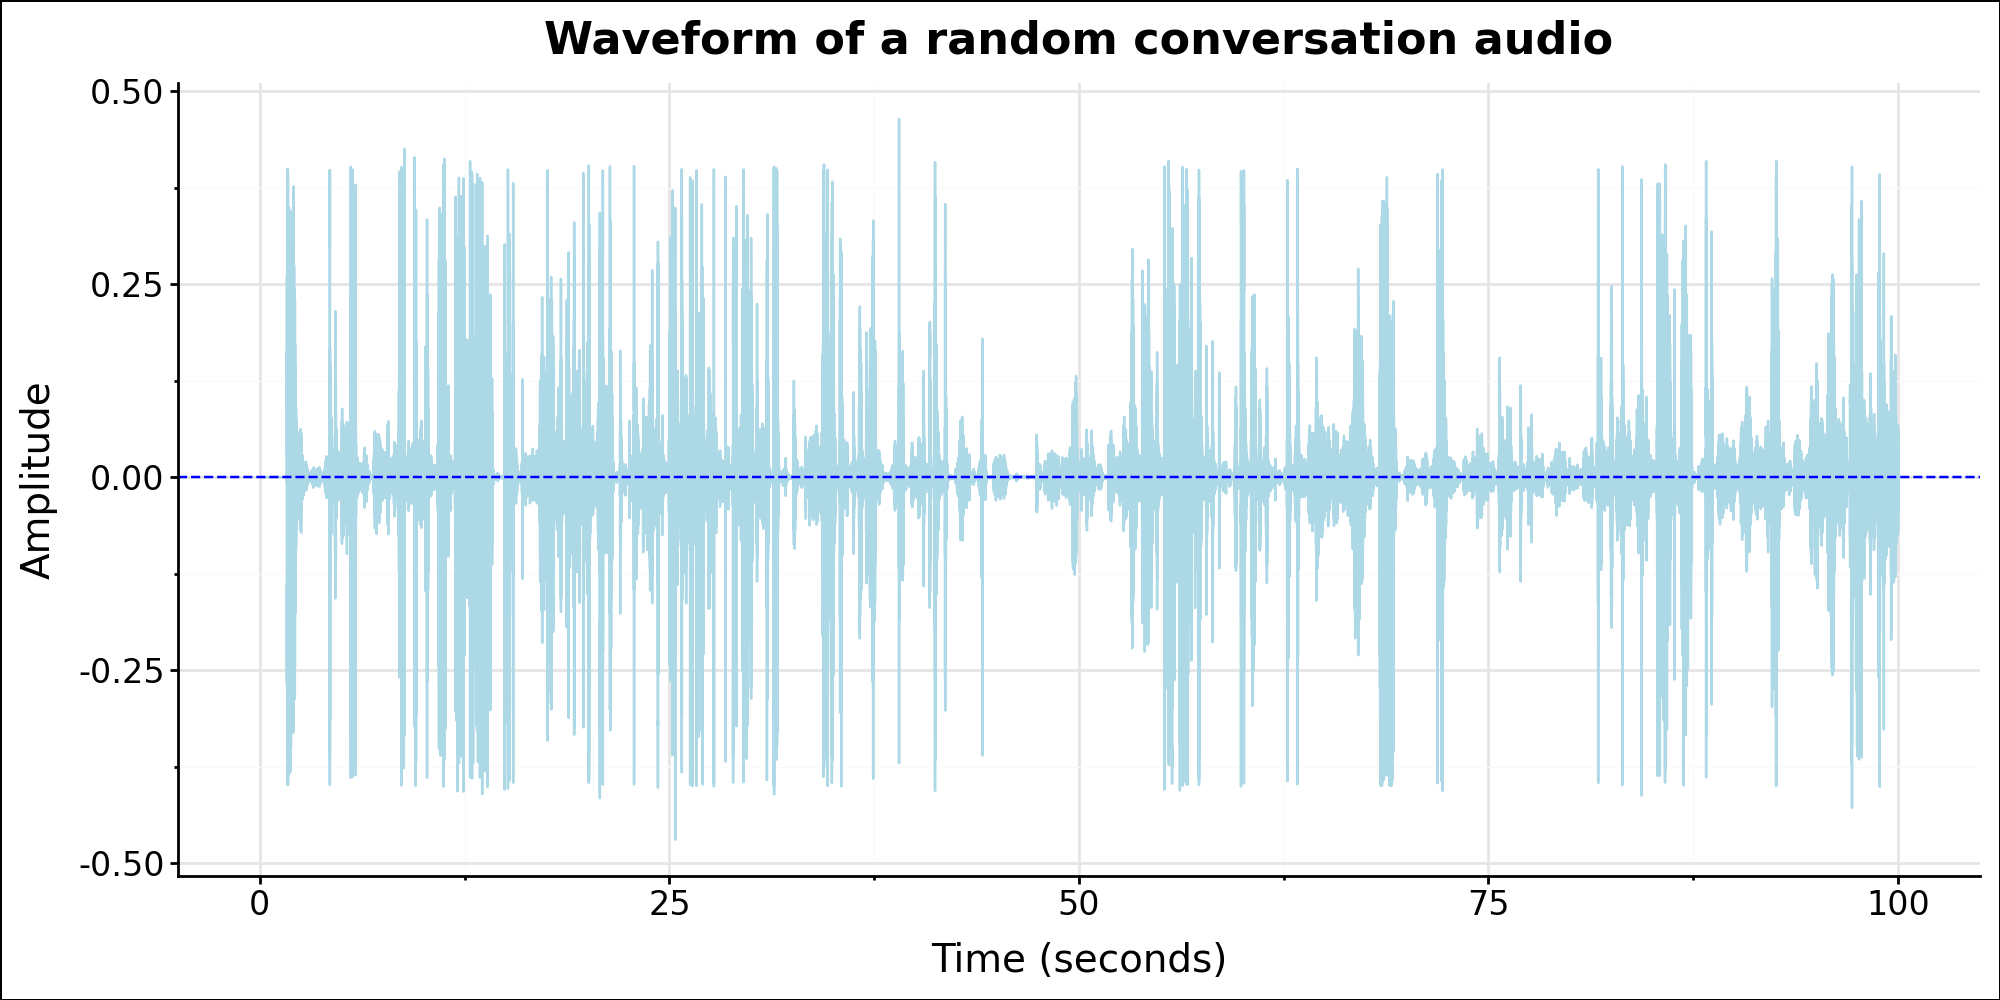

In [7]:
def plot_waveform(yt, sr, start=0, end=None):
    
    if end is None: end = yt.shape[0]
    
    points = pd.DataFrame({
        "Sample Index": range(start, end),
        "Time": [i / sr for i in range(start, end)],
        "Amplitude": yt[start:end]
    })
    
    plot = (
        p9.ggplot(points, p9.aes(x="Time", y="Amplitude"))

        + p9.geom_line(
            color="lightblue", 
            size=0.5)
        + p9.geom_hline(
            yintercept=0, 
            linetype="dashed", 
            color="blue")
            
        + p9.labs(
            title="Waveform of a random conversation audio", 
            x="Time (seconds)", 
            y="Amplitude")
    )

    return plot

# Plot the first 100 seconds of the audio
start = 0
end = sr * 100 # 100 seconds
plot_waveform(yt, sr, start, end)

Because a waveform alone does not show who spoke or the turn‑taking structure, analyzing conversation audio typically requires either transcribing the recording and using NLP to map utterances to speakers (the approach used by [Di Stasi et al. (2023)](https://psycnet.apa.org/record/2024-16512-001), who transcribed single‑file sessions with Trint and then annotated turns), or recording each participant on separate channels and applying voice‑activity detection to each file.

For the demo below we rely on CANDOR's pre‑aligned per‑turn transcripts (loaded by the converter above), so the dynamics extractor can operate directly on utterance‑level data without any additional audio processing.

### Calculate Conversation Dynamics metrics

Inspired from Di Stasi et al (2024), we calcaulte the following metrics that summarize conversation dynamics across 7 core dimensions.

- **Speaking Time:** Proportion of time a negotiator spends talking during the negotiation.
  - *Metric:* Percentage of total conversation time occupied by the negotiator's speech.

- **Turn Length:** Duration of each speech turn.
  - *Metrics:*
    - *Median turn length:* Middle value of turn lengths across all turns.
    - *Coefficient of variation:* Ratio of the standard deviation to the average turn length, reflecting variability.

- **Pauses:** Frequency and duration of silences between speech turns.
  - *Metric:* Time spent pausing relative to speaking time.

- **Speech Rate:** Words spoken per minute.
  - *Metric:* Average rate at which each negotiator speaks.

- **Interruptions:** Instances where a negotiator speaks over or cuts off the counterpart.
  - *Metric:* Total number of interruptions initiated by the negotiator.

- **Backchannels:** Short acknowledgments or feedback (e.g., "mm-hmm", "okay") during counterpart's speech.
  - *Metric:* Frequency of backchanneling behavior.

- **Response Time:** Latency between the end of one person's speech and the other's response.
  - *Metric:* Average time delay before responding to a counterpart’s turn.[1]

These dimensions reflect both individual style and dynamic structure of negotiation conversations.

We provide implementation of all of these metrics in `candy/transformers/converstion_dynamics`. Similar to `convertors`, we provide a template that demonstrates how to include your own metrics.

In [10]:
# necessary transformers for the calculating metrics
from candy.transformers import ConversationDynamicsTransformer

# extract conversation dynamics features from Di Stasi et al (2024)
dynamics_extractor = ConversationDynamicsTransformer()
dynamics_extractor.register_metrics([
    "speaking_time",
    "turn_length",
    "pauses",
    "speaker_rate",
    "backchannels",
    "response_time"
])

corpus = dynamics_extractor.transform(corpus)

Extracting feature: speaking_time
Extracting feature: turn_length
Extracting feature: pauses
Extracting feature: speaker_rate
Extracting feature: backchannels
Extracting feature: response_time


In [22]:
random_conversation.retrieve_meta("conversation_dynamics_features")

{'speaking_time': {'speaker_00_speaking_time': 25.878451334258752,
  'speaker_01_speaking_time': 48.25697979330558,
  'speaker_02_speaking_time': 4.4061391331173825},
 'turn_length': {'speaker_00_turn_length_median': 1.0715625000000273,
  'speaker_01_turn_length_median': 3.408749999999941,
  'speaker_02_turn_length_median': 1.0462499999999864,
  'speaker_00_turn_length_mean': 3.111119505494496,
  'speaker_01_turn_length_mean': 4.7994034090909095,
  'speaker_02_turn_length_mean': 1.752852272727272,
  'speaker_00_turn_length_cv': 1.4093744360895675,
  'speaker_01_turn_length_cv': 1.1078826311225543,
  'speaker_02_turn_length_cv': 1.183873334533108,
  'speaker_01_turn_length_predictability': 0.02693247410562108,
  'speaker_02_turn_length_predictability': 0.090925233978263,
  'turn_length_adaptability': -0.18615140362271781},
 'pauses': {'speaker_00_avg_pause_pct': 0.1660121109367106,
  'speaker_01_avg_pause_pct': 0.1183859262810837,
  'speaker_02_avg_pause_pct': 0.4563989860681618},
 'spe

In [1]:
from convokit import Corpus

# load the converted corpus
corpus = Corpus(filename="results/candor_transformed_transcripts")

random_conversation = corpus.random_conversation()
random_conversation.retrieve_meta("conversation_dynamics_features")

/home/ssubrahmanya/candy/.venv/lib/python3.9/site-packages/convokit/coordination/coordination.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


{'speaking_time': {'5ee2916b70aa643be19c0036_value': 62.385321100917416,
  '5efe907ba8384039f55a9625_value': 37.61467889908259},
 'turn_length': {'5ee2916b70aa643be19c0036_median': 1.3599999999997863,
  '5efe907ba8384039f55a9625_median': 0.8450000000000273,
  '5ee2916b70aa643be19c0036_mean': 2.752941176470579,
  '5efe907ba8384039f55a9625_mean': 1.6598615916954975,
  '5ee2916b70aa643be19c0036_cv': 3.732326276602758,
  '5efe907ba8384039f55a9625_cv': 1.355437135472941,
  '5ee2916b70aa643be19c0036_predictability': 0.004320805148938235,
  '5efe907ba8384039f55a9625_predictability': 0.020902643242996677,
  'adaptability': -0.017700131653970944},
 'pauses': {},
 'speaker_rate': {'5ee2916b70aa643be19c0036_median': 181.81818181819844,
  '5efe907ba8384039f55a9625_median': 190.47619047620904,
  '5ee2916b70aa643be19c0036_cv': 0.46524704825426844,
  '5efe907ba8384039f55a9625_cv': 0.48825892425667095,
  '5ee2916b70aa643be19c0036_predictability': 0.06151520245928292,
  '5efe907ba8384039f55a9625_predic

In [14]:
random_conversation.id

'502b06e6-7054-4f5b-9558-a0dc66c0164c'

In [9]:
# load the converted corpus
corpus = Corpus(filename="results/candor_transformed_transcripts")

random_conversation = corpus.random_conversation()
random_conversation.meta.to_dict()

{'you_are_humble': {'55a43cf3fdf99b02ff6cb0b4': 9.0,
  '5ef6bb87b83f3b000a3f04ae': 9.0},
 'your_bfi_4': {'55a43cf3fdf99b02ff6cb0b4': 3.0,
  '5ef6bb87b83f3b000a3f04ae': 2.0},
 'i_think_my_status': {'55a43cf3fdf99b02ff6cb0b4': 7.0,
  '5ef6bb87b83f3b000a3f04ae': 6.0},
 'you_disclosed': {'55a43cf3fdf99b02ff6cb0b4': 6.0,
  '5ef6bb87b83f3b000a3f04ae': 4.0},
 'my_bfi_3': {'55a43cf3fdf99b02ff6cb0b4': 2.0,
  '5ef6bb87b83f3b000a3f04ae': 3.0},
 'who_i_talked_to_most_past24': {'55a43cf3fdf99b02ff6cb0b4': nan,
  '5ef6bb87b83f3b000a3f04ae': nan},
 'my_sad_pre_covid': {'55a43cf3fdf99b02ff6cb0b4': nan,
  '5ef6bb87b83f3b000a3f04ae': nan},
 'overall_arousal': {'55a43cf3fdf99b02ff6cb0b4': 6.0,
  '5ef6bb87b83f3b000a3f04ae': 9.0},
 'date': {'55a43cf3fdf99b02ff6cb0b4': '2020-10-17',
  '5ef6bb87b83f3b000a3f04ae': '2020-10-17'},
 'you_tried_to_impress': {'55a43cf3fdf99b02ff6cb0b4': 5.0,
  '5ef6bb87b83f3b000a3f04ae': 4.0},
 'arousal': {'55a43cf3fdf99b02ff6cb0b4': 6.0, '5ef6bb87b83f3b000a3f04ae': 9.0},
 'i_am_h

In [ ]:
from candy.transformers import ConversationDynamicsTransformer

dynamics_extractor = ConversationDynamicsTransformer()
dynamics_extractor.register_metrics([
    "speaking_time",
    "turn_length",
    "speaker_rate",
    "backchannels",
    "response_time",
])

corpus = dynamics_extractor.transform(corpus)


,speaking_time_speaker_0_value,speaking_time_speaker_1_value,turn_length_speaker_0_median,turn_length_speaker_1_median,turn_length_speaker_0_mean,turn_length_speaker_1_mean,turn_length_speaker_0_cv,turn_length_speaker_1_cv,turn_length_speaker_1_predictability,turn_length_speaker_0_predictability,...,response_time_speaker_1_median,response_time_speaker_0_cv,response_time_speaker_1_cv,response_time_speaker_1_predictability,response_time_speaker_0_predictability,response_time_adaptability,begin_affect_speaker_0,begin_affect_speaker_1,end_affect_speaker_0,end_affect_speaker_1
conversation_id,,,,,,,,,,,,,,,,,,,,,
502b06e6-7054-4f5b-9558-a0dc66c0164c,26.199921,73.800079,0.55,1.940,1.208617,3.394655,1.286454,1.228753,0.097773,-0.008432,...,-0.030,10.525175,3.601489,0.021632,-0.017439,0.088742,4.0,5.0,6.0,6.0
67836c1d-1334-41a0-a33a-4f788e8b6fb3,59.045094,40.954906,1.71,1.320,4.761478,3.302660,1.537839,1.433618,0.147504,0.136527,...,0.085,2.259874,2.670131,0.037714,-0.070328,0.085145,6.0,6.0,6.0,7.0
754240f9-69ef-481c-8484-3de526bf96a3,62.385321,37.614679,1.36,0.845,2.752941,1.659862,3.732326,1.355437,0.020903,0.004321,...,-0.100,-1.924512,-3.222918,0.056938,-0.005798,-0.226848,9.0,7.0,9.0,9.0
d3b4cd4a-45a9-46f7-95b2-dbd513ffa651,49.265912,50.734088,0.74,0.720,1.892855,1.951037,1.417227,1.284182,0.110428,0.209568,...,-0.110,-2.201488,-8.652546,-0.011516,0.070625,-0.234324,5.0,5.0,9.0,8.0
95d7d1a0-eeca-4eda-9b1d-9e72edd0c560,49.622525,50.377475,1.32,0.750,2.475092,2.512747,1.235085,9.320577,0.101029,0.298091,...,-0.190,-2.221562,-2.708003,0.071680,-0.081262,-0.123510,4.0,7.0,8.0,9.0


### Descriptive statistics

Summary (M, SD, Min, Max) of the extracted conversation dynamics features. Speaker-level variables (e.g. speaking share, median turn length) are pooled across both speakers in each conversation; conversation-level variables (adaptability, predictability) are summarized over conversations.

In [14]:
import pandas as pd

features = pd.read_csv("results/conversation_dynamics_features.csv")
features["stat"] = features["feature"].apply(lambda f: f.split(".")[-1] if "speaker" in f else f)

summary = features \
    .groupby(["metric", "stat"]) \
    .agg({"value": ["mean", "std", "min", "max"]}) \
    .round(2)

summary.columns = ["mean", "std", "min", "max"]
summary = summary.reset_index()

summary

,metric,stat,mean,std,min,max
0,backchannels,value,49.79,9.84,26.35,68.02
1,response_time,adaptability,-0.16,0.10,-0.42,0.09
2,response_time,cv,-5.62,16.14,-92.90,25.22
3,response_time,median,-0.13,0.09,-0.29,0.28
4,response_time,predictability,0.01,0.09,-0.16,0.50
5,speaker_rate,adaptability,0.04,0.09,-0.08,0.27
6,speaker_rate,cv,0.57,0.10,0.39,0.89
7,speaker_rate,median,169.69,21.24,111.85,229.07
8,speaker_rate,predictability,0.05,0.05,-0.06,0.18
9,speaking_time,value,50.00,13.67,22.90,77.10


In [ ]:
features = pd.read_csv("results/conversation_dynamics_features.csv")
features["stat"] = features["feature"].apply(lambda f: f.split(".")[-1] if "speaker" in f else f)

def summarize(metric, stat, scale=1.0):
    values = features.loc[
        (features["metric"] == metric) & (features["stat"] == stat), "value"
    ].astype(float) * scale
    return {
        "M": values.mean(),
        "SD": values.std(),
        "Min": values.min(),
        "Max": values.max(),
    }

table_spec = [
    ("Speaking Time", None),
    ("Speaking share",              ("speaking_time", "value",         1 / 100)),
    ("Turn Length", None),
    ("Median turn length",          ("turn_length",   "median",         1)),
    ("Turn length variability (CV)",("turn_length",   "cv",             1)),
    ("Turn length adaptability",    ("turn_length",   "adaptability",   1)),
    ("Turn length predictability",  ("turn_length",   "predictability", 1)),
    ("Speech Rate", None),
    ("Median speech rate",          ("speaker_rate",  "median",         1)),
    ("Speech rate variability (CV)",("speaker_rate",  "cv",             1)),
    ("Speech rate adaptability",    ("speaker_rate",  "adaptability",   1)),
    ("Speech rate predictability",  ("speaker_rate",  "predictability", 1)),
    ("Backchannels", None),
    ("Backchannel proportion",      ("backchannels",  "value",          1 / 100)),
    ("Response Time", None),
    ("Median response time",        ("response_time", "median",         1)),
    ("Response time variability (CV)",("response_time","cv",           1)),
    ("Response time adaptability",  ("response_time", "adaptability",   1)),
    ("Response time predictability",("response_time", "predictability", 1)),
]

rows = []
for label, spec in table_spec:
    if spec is None:
        rows.append({"Variable": label, "M": "", "SD": "", "Min": "", "Max": ""})
    else:
        s = summarize(*spec)
        rows.append({"Variable": label, **{k: f"{v:.2f}" for k, v in s.items()}})

summary_table = pd.DataFrame(rows)
summary_table

In [13]:
import statsmodels.formula.api as smf

# average begin_affect across both speakers as a single conversation-level predictor
df_model = df_dynamics.copy()
df_model["begin_affect_avg"] = df_model[["begin_affect_speaker_0", "begin_affect_speaker_1"]].mean(axis=1)

# dynamics feature columns (exclude affect columns)
dynamics_cols = [c for c in df_dynamics.columns if "affect" not in c]

results = {}
for col in dynamics_cols:
    data = df_model[[col, "begin_affect_avg"]].dropna()
    # sanitize column name for formula use
    safe_col = col.replace(".", "_").replace("-", "_")
    data = data.rename(columns={col: safe_col})
    model = smf.ols(f"{safe_col} ~ begin_affect_avg", data=data).fit()
    results[col] = model

for col, res in results.items():
    print(f"\n{'='*60}")
    print(f"Outcome: {col}")
    print(f"{'='*60}")
    print(res.summary())



Outcome: speaking_time_speaker_0_value
                                  OLS Regression Results                                 
Dep. Variable:     speaking_time_speaker_0_value   R-squared:                       0.000
Model:                                       OLS   Adj. R-squared:                 -0.036
Method:                            Least Squares   F-statistic:                 0.0003192
Date:                           Fri, 06 Mar 2026   Prob (F-statistic):              0.986
Time:                                   10:04:27   Log-Likelihood:                -120.61
No. Observations:                             30   AIC:                             245.2
Df Residuals:                                 28   BIC:                             248.0
Df Model:                                      1                                         
Covariance Type:                       nonrobust                                         
                       coef    std err          t      P>|t|

### Modeling

In [33]:
import warnings
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore", category=UserWarning)

In [34]:
features = pd.read_csv("results/audiophile/conversation_dynamics_features.csv")
parts = features["feature"].str.split('.', expand=True)
features["speaker"] = parts[1].astype(int)
features["sub"] = parts[2]
features["metric"] = features["metric"] + "." + features["sub"]

features_wide = features \
    .pivot_table(
        index=["conversation_id", "speaker"],
        columns="metric", 
        values="value",
        aggfunc="first"
    ) \
    .reset_index()

In [35]:
survey = pd \
    .read_csv(
        "data/candor_transcripts/merged_survey.csv",
        dtype={
            "user_id": str,
            "partner_id": str,
            "convo_id": str
        }
    ) \
    .drop_duplicates(subset=["convo_id", "user_id"]) \
    .reset_index(drop=True) \
    .rename(columns={"convo_id": "conversation_id"})

survey["change_valence"] = survey["affect"]  - survey["pre_affect"]
survey["change_arousal"] = survey["arousal"] - survey["pre_arousal"]

In [36]:
speakers_map = survey[["conversation_id", "user_id"]] \
    .sort_values(["conversation_id", "user_id"])

speakers_map["speaker"] = np.arange(speakers_map.shape[0]) % 2
features_wide = pd.merge(features_wide, speakers_map, on=["conversation_id", "speaker"], how="inner")

In [37]:
keep = [
    "conversation_id", "user_id", "partner_id",
    "change_valence", "change_arousal",
    "my_extraversion", "my_agreeable", "my_conscientious", "my_neurotic", "my_open",
]

apim = survey[keep] \
    .merge(features_wide, on=["conversation_id", "user_id"], how="inner")

partnered_vars = [
    "speaking_time.share",
    "turn_length.median", "turn_length.cv",
    "turn_length.adaptability", "turn_length.predictability",
    "speaker_rate.median", "speaker_rate.cv",
    "speaker_rate.adaptability", "speaker_rate.predictability",
    "backchannels.turns_total", "backchannels.backchannel_n", "backchannels.backchannel_prop",
    "response_time.median", "response_time.cv",
    "response_time.adaptability", "response_time.predictability",
]

partner = apim[["conversation_id", "user_id"] + partnered_vars] \
    .rename(columns={
        "user_id": "partner_id",
        **{v: f"partner.{v}" for v in partnered_vars},
    })

all_vars = partnered_vars + [f"partner.{v}" for v in partnered_vars]

apim = apim \
    .merge(partner, on=["conversation_id", "partner_id"], how="left") \
    .dropna(subset=all_vars) \
    .reset_index(drop=True)

for v in all_vars:
    apim[f"{v}.z"] = (apim[v] - apim[v].mean()) / apim[v].std(ddof=1)

print(f"apim: {len(apim)} rows ({apim['conversation_id'].nunique()} conversations)")
apim.head()

apim: 3144 rows (1572 conversations)


,conversation_id,user_id,partner_id,change_valence,change_arousal,my_extraversion,my_agreeable,my_conscientious,my_neurotic,my_open,...,partner.speaker_rate.cv.z,partner.speaker_rate.adaptability.z,partner.speaker_rate.predictability.z,partner.backchannels.turns_total.z,partner.backchannels.backchannel_n.z,partner.backchannels.backchannel_prop.z,partner.response_time.median.z,partner.response_time.cv.z,partner.response_time.adaptability.z,partner.response_time.predictability.z
0,4035f17c-61f5-4976-9b10-c682def66b36,5d0fb996286e1700010de2c1,5f0e50c3a8d93519188a7525,-1.0,2.0,4.000000,2.666667,3.333333,3.333333,3.000000,...,-1.397730,-2.541895,-2.376192,-1.646391,-1.306234,-0.658139,2.050899,-0.455426,0.086575,-1.934286
1,4035f17c-61f5-4976-9b10-c682def66b36,5f0e50c3a8d93519188a7525,5d0fb996286e1700010de2c1,1.0,0.0,3.000000,2.000000,3.666667,3.333333,4.333333,...,-0.659611,0.534121,-0.244868,-1.646391,-1.754663,-2.768512,1.250796,-0.392885,-0.744465,0.242300
2,46561ffd-6a0b-4958-b158-8e1d3cad91e2,5ebbfc3729e14e0372002deb,5f070f6f0b00e807015e68d4,-2.0,-1.0,3.666667,4.666667,3.666667,1.333333,4.000000,...,2.369213,0.757949,-0.238295,-0.134280,-0.462762,-0.674888,1.170786,-0.512667,-0.922360,-1.156842
3,46561ffd-6a0b-4958-b158-8e1d3cad91e2,5f070f6f0b00e807015e68d4,5ebbfc3729e14e0372002deb,0.0,2.0,3.000000,3.666667,2.000000,3.666667,2.666667,...,-0.321274,0.153746,-0.174655,-0.127927,-0.014334,0.230194,1.970889,-0.613901,-0.069888,0.348685
4,a1ab2d0e-1546-414b-945e-a59bad758e77,5dd5db1ded7ea4574c7bc996,5eac6e70e481222bfb2a8872,0.0,0.0,3.666667,3.666667,3.000000,2.333333,3.000000,...,0.436714,0.092709,-0.002507,-0.159694,-0.388024,-0.491696,-0.109378,-0.199184,1.229729,0.535526


In [38]:
predictors = ["speaking_time.share.z"] + [
    f"{prefix}{v}.z"
    for v in partnered_vars if v != "speaking_time.share"
    for prefix in ("", "partner.")
]
rhs = " + ".join(f"Q('{p}')" for p in predictors)


def fit_mixed(outcome, data):
    sub = data.dropna(subset=[outcome])
    formula = f"{outcome} ~ {rhs}"
    last_err = None
    for method in ("powell", "bfgs", "lbfgs", "cg", "nm"):
        try:
            return smf \
                .mixedlm(formula, sub, groups=sub["conversation_id"]) \
                .fit(reml=False, method=method)
        except np.linalg.LinAlgError as e:
            last_err = e
    raise RuntimeError(f"all optimizers failed for {outcome}: {last_err}")


def coef_table(res, est="fe_params", se="bse_fe"):
    out = pd.DataFrame({
        "est": getattr(res, est),
        "se": getattr(res, se),
        "p": res.pvalues,
    })
    keys = [f"Q('{p}')" for p in predictors]
    return out.loc[[k for k in keys if k in out.index]]


res_valence = fit_mixed("change_valence", apim)
res_arousal = fit_mixed("change_arousal", apim)

affect_table = coef_table(res_valence) \
    .rename(columns=lambda c: f"valence_{c}") \
    .join(coef_table(res_arousal).rename(columns=lambda c: f"arousal_{c}"))

print(f"change_valence: n={int(res_valence.nobs)}, "
      f"convos={apim.dropna(subset=['change_valence'])['conversation_id'].nunique()}, "
      f"convo-var={float(res_valence.cov_re.iloc[0, 0]):.3f}")
print(f"change_arousal: n={int(res_arousal.nobs)}, "
      f"convos={apim.dropna(subset=['change_arousal'])['conversation_id'].nunique()}, "
      f"convo-var={float(res_arousal.cov_re.iloc[0, 0]):.3f}")
affect_table.round(3)

change_valence: n=3090, convos=1570, convo-var=0.253
change_arousal: n=3090, convos=1570, convo-var=0.029


,valence_est,valence_se,valence_p,arousal_est,arousal_se,arousal_p
Q('speaking_time.share.z'),0.041,0.045,0.362,-0.059,0.056,0.295
Q('turn_length.median.z'),0.080,0.057,0.162,0.121,0.068,0.076
Q('partner.turn_length.median.z'),0.028,0.057,0.626,-0.026,0.068,0.706
Q('turn_length.cv.z'),-0.066,0.031,0.032,-0.030,0.037,0.411
Q('partner.turn_length.cv.z'),0.016,0.031,0.595,-0.072,0.037,0.048
Q('turn_length.adaptability.z'),-0.076,0.051,0.133,0.053,0.062,0.393
Q('partner.turn_length.adaptability.z'),0.070,0.051,0.169,-0.020,0.062,0.741
Q('turn_length.predictability.z'),0.024,0.038,0.524,0.047,0.046,0.300
Q('partner.turn_length.predictability.z'),0.005,0.038,0.895,0.010,0.046,0.834
Q('speaker_rate.median.z'),0.009,0.034,0.788,0.003,0.041,0.946


In [39]:
personality = ["my_extraversion", "my_agreeable", "my_conscientious", "my_neurotic", "my_open"]

big5 = {p: fit_mixed(p, apim) for p in personality}

big5_table = pd.concat(
    [
        coef_table(big5[p]).rename(columns=lambda c, p=p: f"{p.replace('my_', '')}_{c}")
        for p in personality
    ],
    axis=1,
)

for p, res in big5.items():
    convos = apim.dropna(subset=[p])["conversation_id"].nunique()
    print(f"{p}: n={int(res.nobs)}, convos={convos}, "
          f"convo-var={float(res.cov_re.iloc[0, 0]):.3f}")

big5_table.round(3)

my_extraversion: n=3089, convos=1570, convo-var=0.052
my_agreeable: n=3089, convos=1570, convo-var=0.000
my_conscientious: n=3089, convos=1570, convo-var=0.000
my_neurotic: n=3089, convos=1570, convo-var=0.021
my_open: n=3089, convos=1570, convo-var=0.003


,extraversion_est,extraversion_se,extraversion_p,agreeable_est,agreeable_se,agreeable_p,conscientious_est,conscientious_se,conscientious_p,neurotic_est,neurotic_se,neurotic_p,open_est,open_se,open_p
Q('speaking_time.share.z'),0.194,0.029,0.000,-0.019,0.025,0.451,-0.052,0.031,0.088,-0.017,0.035,0.620,0.053,0.025,0.032
Q('turn_length.median.z'),0.011,0.036,0.762,0.037,0.030,0.221,-0.006,0.037,0.864,-0.044,0.043,0.303,0.068,0.030,0.025
Q('partner.turn_length.median.z'),0.123,0.035,0.001,0.050,0.030,0.096,0.061,0.037,0.099,0.001,0.042,0.987,0.069,0.030,0.021
Q('turn_length.cv.z'),-0.042,0.019,0.030,-0.006,0.016,0.728,0.036,0.020,0.072,-0.003,0.023,0.885,0.002,0.016,0.918
Q('partner.turn_length.cv.z'),0.056,0.019,0.004,-0.033,0.016,0.044,-0.019,0.020,0.324,0.011,0.023,0.643,-0.008,0.016,0.619
Q('turn_length.adaptability.z'),0.012,0.032,0.711,0.022,0.027,0.419,-0.046,0.033,0.170,0.021,0.038,0.577,0.018,0.027,0.519
Q('partner.turn_length.adaptability.z'),-0.023,0.032,0.476,-0.040,0.027,0.148,0.040,0.034,0.234,-0.065,0.038,0.089,-0.020,0.027,0.466
Q('turn_length.predictability.z'),0.018,0.024,0.441,0.000,0.020,0.989,-0.013,0.025,0.610,0.014,0.028,0.620,0.032,0.020,0.112
Q('partner.turn_length.predictability.z'),0.029,0.024,0.223,-0.006,0.020,0.777,-0.010,0.025,0.686,-0.066,0.028,0.019,0.007,0.020,0.733
Q('speaker_rate.median.z'),0.101,0.021,0.000,-0.096,0.018,0.000,0.010,0.022,0.633,-0.034,0.025,0.181,0.010,0.018,0.585


In [40]:
def fit_ols(outcome, data):
    return smf \
        .ols(f"{outcome} ~ {rhs}", data=data.dropna(subset=[outcome])) \
        .fit()


big5_ols = {p: fit_ols(p, apim) for p in personality}

big5_ols_table = pd.concat(
    [
        coef_table(big5_ols[p], est="params", se="bse") \
            .rename(columns=lambda c, p=p: f"{p.replace('my_', '')}_{c}")
        for p in personality
    ],
    axis=1,
)

for p, res in big5_ols.items():
    print(f"{p}: n={int(res.nobs)}, R^2={res.rsquared:.3f}")

big5_ols_table.round(3)

my_extraversion: n=3089, R^2=0.078
my_agreeable: n=3089, R^2=0.024
my_conscientious: n=3089, R^2=0.027
my_neurotic: n=3089, R^2=0.018
my_open: n=3089, R^2=0.023


,extraversion_est,extraversion_se,extraversion_p,agreeable_est,agreeable_se,agreeable_p,conscientious_est,conscientious_se,conscientious_p,neurotic_est,neurotic_se,neurotic_p,open_est,open_se,open_p
Q('speaking_time.share.z'),0.194,0.030,0.000,-0.019,0.025,0.454,-0.052,0.031,0.090,-0.017,0.035,0.626,0.053,0.025,0.033
Q('turn_length.median.z'),0.011,0.036,0.763,0.037,0.030,0.224,-0.006,0.037,0.865,-0.044,0.043,0.305,0.068,0.030,0.026
Q('partner.turn_length.median.z'),0.123,0.036,0.001,0.050,0.030,0.097,0.061,0.037,0.101,0.001,0.043,0.989,0.069,0.030,0.022
Q('turn_length.cv.z'),-0.042,0.019,0.030,-0.006,0.016,0.729,0.036,0.020,0.073,-0.003,0.023,0.888,0.002,0.016,0.919
Q('partner.turn_length.cv.z'),0.055,0.019,0.004,-0.033,0.016,0.045,-0.019,0.020,0.327,0.011,0.023,0.643,-0.008,0.016,0.621
Q('turn_length.adaptability.z'),0.012,0.033,0.719,0.022,0.027,0.422,-0.046,0.034,0.173,0.021,0.039,0.579,0.018,0.027,0.522
Q('partner.turn_length.adaptability.z'),-0.023,0.033,0.482,-0.040,0.028,0.150,0.040,0.034,0.237,-0.065,0.039,0.093,-0.020,0.027,0.470
Q('turn_length.predictability.z'),0.019,0.024,0.438,0.000,0.020,0.989,-0.013,0.025,0.612,0.014,0.029,0.622,0.032,0.020,0.114
Q('partner.turn_length.predictability.z'),0.029,0.024,0.233,-0.006,0.020,0.778,-0.010,0.025,0.688,-0.066,0.029,0.020,0.007,0.020,0.734
Q('speaker_rate.median.z'),0.100,0.021,0.000,-0.096,0.018,0.000,0.010,0.022,0.635,-0.034,0.026,0.184,0.010,0.018,0.587
